# IntelliPulse V2.2 — Class-Weighted Logistic Regression

---

## Overview

### What we've done so far

| Experiment | What changed | Key result |
|------------|-------------|------------|
| **V1** | Baseline Logistic Regression @ threshold 0.50 | Recall = 55.88%, F1 = 60.40%, ROC-AUC = 84.21% |
| **V2.1** | Same model, threshold lowered to 0.27 | Recall ↑ to 78.34%, F1 ↑ to 62.14%, but FP ↑ by 167 |

### What V2.2 investigates

In V2.1 we changed the **decision threshold** — the cutoff applied *after* the model produces probabilities. The model itself was unchanged.

In V2.2 we change the **model's training objective** by introducing **class weighting**. This means the model itself will be different — it will learn different coefficients because it pays more attention to the minority class (churners) during training.

### Why class weighting?

Our target is imbalanced (~73% No Churn vs. ~27% Churn). A standard Logistic Regression minimises overall log-loss, which naturally favours the majority class. With `class_weight="balanced"`, scikit-learn **automatically upweights the minority class** during training:

```
weight_class_k = n_samples / (n_classes × n_samples_class_k)
```

This makes misclassifying a churner more "expensive" to the optimiser than misclassifying a non-churner, encouraging the model to become more sensitive to the minority class.

### How is this different from threshold optimisation?

| Approach | What changes | Model coefficients | Decision rule |
|----------|-------------|-------------------|--------------|
| **V2.1 — Threshold** | Only the cutoff applied to probabilities | Unchanged (same as V1) | Changed (0.50 → 0.27) |
| **V2.2 — Class weight** | The training loss function | **New coefficients** | Default (0.50) |

Both approaches aim to improve minority-class detection, but they operate at different stages of the prediction pipeline.

---

## Imports and Configuration

In [1]:
import os
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

# ── Configuration ────────────────────────────────────────────────────
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"

print(f"Project root : {PROJECT_ROOT}")
print(f"Random state : {RANDOM_STATE}")

Project root : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse
Random state : 42


---

## Section 1 — Load and Prepare Data (Same as V1)

We replicate the **exact same** data loading, cleaning, feature definition, and train/test split from V1. This ensures that any performance difference between V1 and V2.2 is due solely to the class weighting — not a different split, different features, or different preprocessing.

Using the same `random_state=42` and `stratify=y` guarantees an identical split.

In [2]:
# ── Load raw data ─────────────────────────────────────────────────────
assert RAW_DATA_PATH.exists(), f"Dataset not found at {RAW_DATA_PATH}"
df_raw = pd.read_csv(RAW_DATA_PATH)
df = df_raw.copy()

# ── Fix TotalCharges (same as V1) ────────────────────────────────────
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

# ── Column definitions (same as V1) ──────────────────────────────────
ID_COL = "customerID"
TARGET_COL = "Churn"

NUMERICAL_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
CATEGORICAL_FEATURES = [
    "gender", "Partner", "Dependents",
    "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

# ── Separate X and y ─────────────────────────────────────────────────
X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL].map({"No": 0, "Yes": 1}).astype(int)

# ── Same train/test split as V1 ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"Train churn rate: {y_train.mean():.4f}")
print(f"Test churn rate : {y_test.mean():.4f}")

Training set : 5,634 rows
Test set     : 1,409 rows
Train churn rate: 0.2654
Test churn rate : 0.2654


In [3]:
# ── Load V1 baseline metrics for later comparison ────────────────────
with open(METRICS_DIR / "baseline_v1.json") as f:
    v1_metrics = json.load(f)

# ── Load V2.1 metrics ────────────────────────────────────────────────
with open(METRICS_DIR / "threshold_analysis_v2_1.json") as f:
    v2_1_data = json.load(f)

v2_1_metrics = v2_1_data["provisional_metrics"]
v2_1_threshold = v2_1_data["provisional_threshold"]

print(f"V1 loaded  — ROC-AUC: {v1_metrics['roc_auc']}")
print(f"V2.1 loaded — threshold: {v2_1_threshold}, recall: {v2_1_metrics['recall']}")

V1 loaded  — ROC-AUC: 0.8421
V2.1 loaded — threshold: 0.27, recall: 0.7834


---

## Section 2 — Build the V2.2 Pipeline

The preprocessing is **identical** to V1:

| Feature type | Steps |
|---|---|
| Numerical | `SimpleImputer(strategy="median")` → `StandardScaler()` |
| Categorical | `SimpleImputer(strategy="most_frequent")` → `OneHotEncoder(handle_unknown="ignore")` |

The **only change** is in the classifier:

```python
# V1
LogisticRegression(max_iter=1000, random_state=42, solver="lbfgs")

# V2.2
LogisticRegression(max_iter=1000, random_state=42, solver="lbfgs",
                   class_weight="balanced")   # ← this is the only difference
```

### What does `class_weight="balanced"` do?

It tells scikit-learn to compute class weights inversely proportional to class frequencies:

```
weight_k = n_total / (n_classes × n_k)
```

For our dataset (~73% No, ~27% Yes):
- The "No Churn" class gets a weight < 1 (downweighted).
- The "Churn" class gets a weight > 1 (upweighted).

This makes the model's loss function treat a misclassified churner as more costly than a misclassified non-churner, pushing the model to learn a decision boundary that is more sensitive to the minority class.

In [4]:
# ── Preprocessing (identical to V1) ───────────────────────────────────
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, NUMERICAL_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

# ── V2.2 classifier: class-weighted Logistic Regression ──────────────
model_v2_2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
        class_weight="balanced",  # ← THE ONLY CHANGE FROM V1
    )),
])

print("V2.2 pipeline constructed.")
print(f"  Classifier: {model_v2_2.named_steps['classifier']}")

V2.2 pipeline constructed.
  Classifier: LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


In [5]:
# Show the computed class weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight("balanced", classes=classes, y=y_train)

print("Computed class weights (on training set):")
print(f"  Class 0 (No Churn) : {weights[0]:.4f}")
print(f"  Class 1 (Churn)    : {weights[1]:.4f}")
print(f"  Ratio (Churn/No)   : {weights[1]/weights[0]:.2f}x")
print()
print("The churn class receives ~{:.1f}× more weight than the no-churn class.".format(
    weights[1] / weights[0]
))

Computed class weights (on training set):
  Class 0 (No Churn) : 0.6806
  Class 1 (Churn)    : 1.8843
  Ratio (Churn/No)   : 2.77x

The churn class receives ~2.8× more weight than the no-churn class.


---

## Section 3 — Train the Class-Weighted Model

We fit the V2.2 pipeline on the **training set only**. The test set is not used during training — it remains held out for evaluation.

### Why is this still free from test leakage?

The `Pipeline` + `ColumnTransformer` ensures that:
1. The `StandardScaler` is fitted only on training data statistics (mean, std).
2. The `OneHotEncoder` learns categories only from training data.
3. The `LogisticRegression` coefficients are optimised only on training data.

The test set is only ever `.transform()`-ed and `.predict()`-ed — never `.fit()`-ed on.

In [6]:
# ── Train V2.2 ───────────────────────────────────────────────────────
model_v2_2.fit(X_train, y_train)

print("✓ V2.2 class-weighted Logistic Regression trained on training set.")
print(f"  Training samples: {len(y_train):,}")
print(f"  Features after encoding: {model_v2_2.named_steps['preprocessor'].transform(X_train[:1]).shape[1]}")

✓ V2.2 class-weighted Logistic Regression trained on training set.
  Training samples: 5,634
  Features after encoding: 45


---

## Section 4 — Evaluate V2.2 at Default Threshold (0.50)

We first evaluate with the standard 0.50 threshold to get a direct, apples-to-apples comparison with V1.

In [7]:
# ── Predictions at threshold 0.50 ────────────────────────────────────
y_pred_v2_2 = model_v2_2.predict(X_test)
y_prob_v2_2 = model_v2_2.predict_proba(X_test)[:, 1]

# ── Metrics ──────────────────────────────────────────────────────────
acc_v2_2  = accuracy_score(y_test, y_pred_v2_2)
prec_v2_2 = precision_score(y_test, y_pred_v2_2)
rec_v2_2  = recall_score(y_test, y_pred_v2_2)
f1_v2_2   = f1_score(y_test, y_pred_v2_2)
auc_v2_2  = roc_auc_score(y_test, y_prob_v2_2)

v2_2_metrics_050 = {
    "model": "LogisticRegression_ClassWeighted_V2.2",
    "threshold": 0.50,
    "accuracy": round(acc_v2_2, 4),
    "precision": round(prec_v2_2, 4),
    "recall": round(rec_v2_2, 4),
    "f1_score": round(f1_v2_2, 4),
    "roc_auc": round(auc_v2_2, 4),
}

print("=" * 50)
print("  V2.2 — Test Set Evaluation @ Threshold 0.50")
print("=" * 50)
print(f"  Accuracy  : {acc_v2_2:.4f}")
print(f"  Precision : {prec_v2_2:.4f}")
print(f"  Recall    : {rec_v2_2:.4f}")
print(f"  F1-score  : {f1_v2_2:.4f}")
print(f"  ROC-AUC   : {auc_v2_2:.4f}")
print("=" * 50)

  V2.2 — Test Set Evaluation @ Threshold 0.50
  Accuracy  : 0.7381
  Precision : 0.5043
  Recall    : 0.7834
  F1-score  : 0.6136
  ROC-AUC   : 0.8416


### Classification report

In [8]:
print(classification_report(y_test, y_pred_v2_2,
                            target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### Confusion matrix

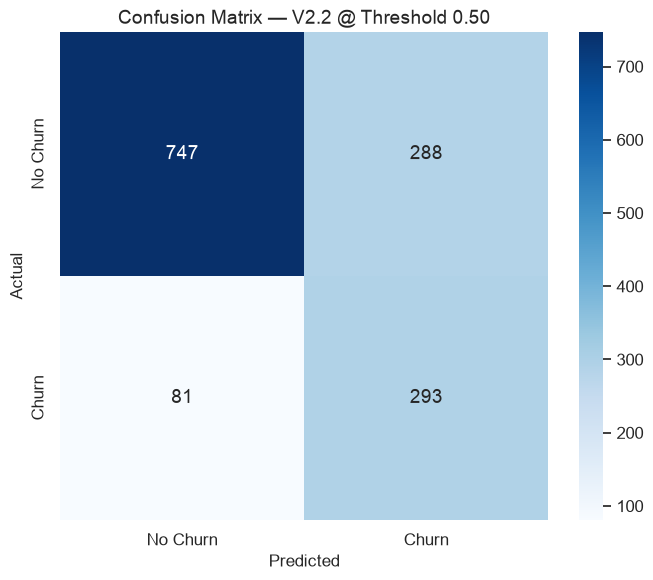

True Negatives  (correct No Churn) : 747
False Positives (false alarms)     : 288
False Negatives (MISSED churners)  : 81
True Positives  (caught churners)  : 293


In [9]:
cm_v2_2 = confusion_matrix(y_test, y_pred_v2_2)
tn_v2_2, fp_v2_2, fn_v2_2, tp_v2_2 = cm_v2_2.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_v2_2, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"],
            annot_kws={"size": 14})
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — V2.2 @ Threshold 0.50")
plt.tight_layout()
plt.show()

print(f"True Negatives  (correct No Churn) : {tn_v2_2}")
print(f"False Positives (false alarms)     : {fp_v2_2}")
print(f"False Negatives (MISSED churners)  : {fn_v2_2}")
print(f"True Positives  (caught churners)  : {tp_v2_2}")

### ROC curve — V1 vs V2.2

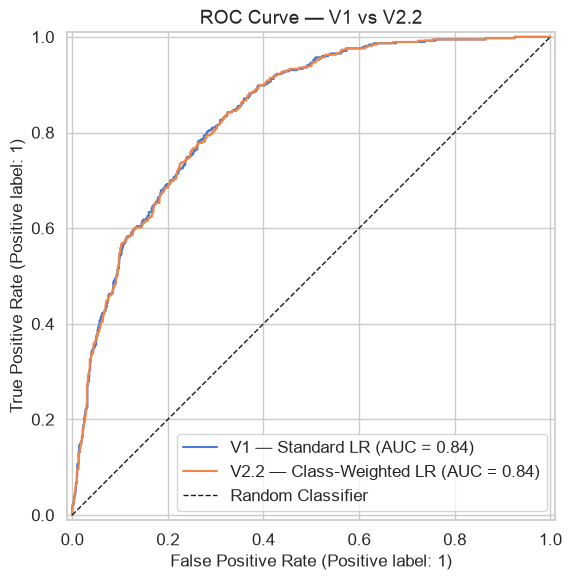

In [10]:
# Load V1 model for ROC comparison
model_v1 = joblib.load(MODEL_DIR / "churn_baseline_v1.joblib")

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(model_v1, X_test, y_test, ax=ax,
                                name="V1 — Standard LR")
RocCurveDisplay.from_estimator(model_v2_2, X_test, y_test, ax=ax,
                                name="V2.2 — Class-Weighted LR")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
ax.set_title("ROC Curve — V1 vs V2.2")
ax.legend()
plt.tight_layout()
plt.show()

---

## Section 5 — V1 vs V2.2 Comparison (Both @ Threshold 0.50)

This is the fairest comparison: both models evaluated at the same default threshold, on the same test set, with the same preprocessing. The **only** difference is `class_weight="balanced"` in V2.2.

In [11]:
# ── V1 confusion matrix components ────────────────────────────────────
y_pred_v1 = model_v1.predict(X_test)
cm_v1 = confusion_matrix(y_test, y_pred_v1)
tn_v1, fp_v1, fn_v1, tp_v1 = cm_v1.ravel()

comparison_v1_v22 = pd.DataFrame({
    "Metric": [
        "Model", "Threshold",
        "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC",
        "True Positives", "False Positives",
        "False Negatives", "True Negatives",
    ],
    "V1 @ 0.50": [
        "Standard LR", "0.50",
        f"{v1_metrics['accuracy']:.4f}",
        f"{v1_metrics['precision']:.4f}",
        f"{v1_metrics['recall']:.4f}",
        f"{v1_metrics['f1_score']:.4f}",
        f"{v1_metrics['roc_auc']:.4f}",
        str(int(tp_v1)), str(int(fp_v1)),
        str(int(fn_v1)), str(int(tn_v1)),
    ],
    "V2.2 @ 0.50": [
        "Class-Weighted LR", "0.50",
        f"{acc_v2_2:.4f}",
        f"{prec_v2_2:.4f}",
        f"{rec_v2_2:.4f}",
        f"{f1_v2_2:.4f}",
        f"{auc_v2_2:.4f}",
        str(int(tp_v2_2)), str(int(fp_v2_2)),
        str(int(fn_v2_2)), str(int(tn_v2_2)),
    ],
})

print("V1 vs V2.2 — Side-by-Side Comparison (Both @ 0.50)")
print("=" * 60)
print(comparison_v1_v22.to_string(index=False))

V1 vs V2.2 — Side-by-Side Comparison (Both @ 0.50)
         Metric   V1 @ 0.50       V2.2 @ 0.50
          Model Standard LR Class-Weighted LR
      Threshold        0.50              0.50
       Accuracy      0.8055            0.7381
      Precision      0.6572            0.5043
         Recall      0.5588            0.7834
       F1-score      0.6040            0.6136
        ROC-AUC      0.8421            0.8416
 True Positives         209               293
False Positives         109               288
False Negatives         165                81
 True Negatives         926               747


In [12]:
# ── Compute deltas for key metrics ────────────────────────────────────
delta_recall = rec_v2_2 - v1_metrics["recall"]
delta_precision = prec_v2_2 - v1_metrics["precision"]
delta_f1 = f1_v2_2 - v1_metrics["f1_score"]
delta_auc = auc_v2_2 - v1_metrics["roc_auc"]
delta_acc = acc_v2_2 - v1_metrics["accuracy"]

print("Changes from V1 → V2.2 (both @ threshold 0.50):")
print(f"  Recall    : {delta_recall:+.4f}  {'↑ IMPROVED' if delta_recall > 0 else '↓ decreased'}")
print(f"  Precision : {delta_precision:+.4f}  {'↑ IMPROVED' if delta_precision > 0 else '↓ decreased'}")
print(f"  F1-score  : {delta_f1:+.4f}  {'↑ IMPROVED' if delta_f1 > 0 else '↓ decreased'}")
print(f"  ROC-AUC   : {delta_auc:+.4f}  {'↑ IMPROVED' if delta_auc > 0 else '↓ decreased' if delta_auc < 0 else '= unchanged'}")
print(f"  Accuracy  : {delta_acc:+.4f}  {'↑ IMPROVED' if delta_acc > 0 else '↓ decreased'}")
print(f"  FN change : {int(fn_v2_2) - int(fn_v1):+d}  (missed churners)")
print(f"  FP change : {int(fp_v2_2) - int(fp_v1):+d}  (false alarms)")

Changes from V1 → V2.2 (both @ threshold 0.50):
  Recall    : +0.2246  ↑ IMPROVED
  Precision : -0.1529  ↓ decreased
  F1-score  : +0.0096  ↑ IMPROVED
  ROC-AUC   : -0.0005  ↓ decreased
  Accuracy  : -0.0674  ↓ decreased
  FN change : -84  (missed churners)
  FP change : +179  (false alarms)


---

## Section 6 — Confusion Matrix Deep Dive

We compare the confusion matrices of V1 and V2.2 side-by-side to understand the concrete impact of class weighting on predictions.

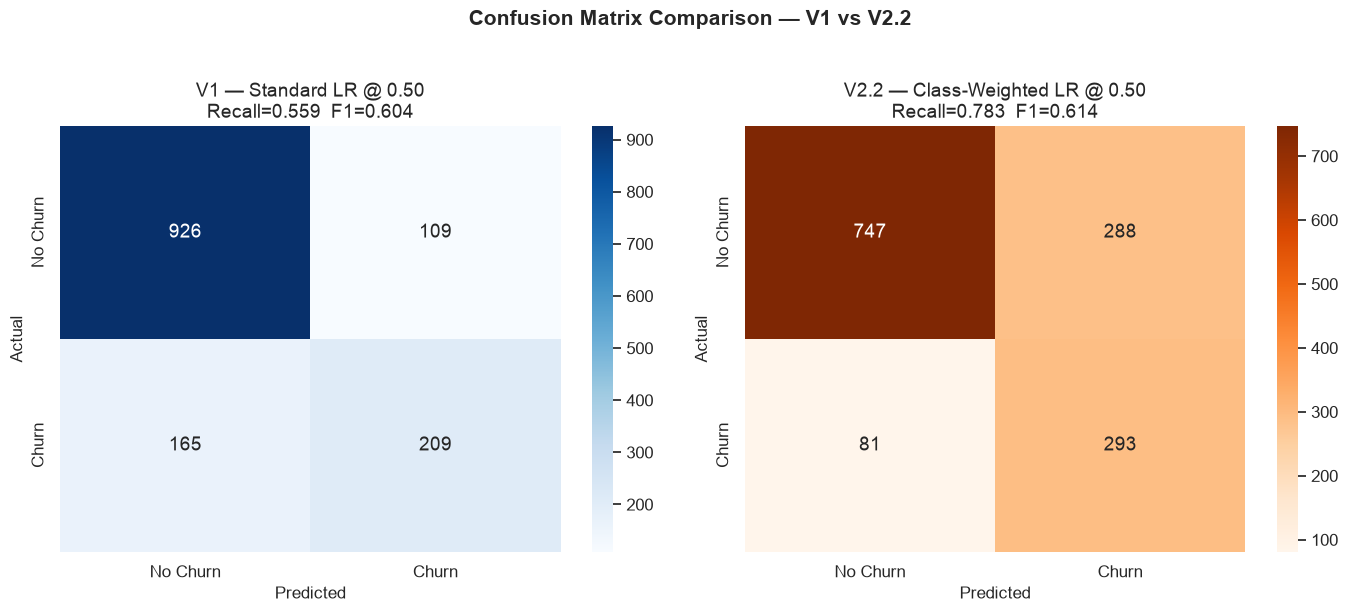

Business impact of class weighting:
  Churners now caught  : 293 (was 209, change: +84)
  Churners still missed: 81 (was 165, change: -84)
  False alarms         : 288 (was 109, change: +179)
  Correct No Churn     : 747 (was 926, change: -179)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# V1
sns.heatmap(cm_v1, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"],
            annot_kws={"size": 14})
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"V1 — Standard LR @ 0.50\nRecall={v1_metrics['recall']:.3f}  F1={v1_metrics['f1_score']:.3f}")

# V2.2
sns.heatmap(cm_v2_2, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"],
            annot_kws={"size": 14})
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title(f"V2.2 — Class-Weighted LR @ 0.50\nRecall={rec_v2_2:.3f}  F1={f1_v2_2:.3f}")

plt.suptitle("Confusion Matrix Comparison — V1 vs V2.2",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Business impact of class weighting:")
print(f"  Churners now caught  : {int(tp_v2_2)} (was {int(tp_v1)}, change: {int(tp_v2_2)-int(tp_v1):+d})")
print(f"  Churners still missed: {int(fn_v2_2)} (was {int(fn_v1)}, change: {int(fn_v2_2)-int(fn_v1):+d})")
print(f"  False alarms         : {int(fp_v2_2)} (was {int(fp_v1)}, change: {int(fp_v2_2)-int(fp_v1):+d})")
print(f"  Correct No Churn     : {int(tn_v2_2)} (was {int(tn_v1)}, change: {int(tn_v2_2)-int(tn_v1):+d})")

### Business trade-off

**False Negatives (missed churners):** Each missed churner is a customer who leaves without the company attempting retention. The company loses that customer's future lifetime value. Reducing FN is the primary goal of improving recall.

**False Positives (false alarms):** Each false positive triggers an unnecessary retention action (e.g., a discount offer, a phone call). This has a cost, but it is typically much smaller than losing a customer entirely. Some false positives may even have a positive side effect — loyal customers receiving a "thank you" offer may feel valued.

The goal is **not** to minimise one number in isolation, but to find a balance where the cost of additional false alarms is outweighed by the value of additional caught churners.

---

## Section 7 — Threshold Analysis for V2.2

Class weighting changes the model's **probability calibration** — the distribution of predicted probabilities shifts. This means the optimal threshold for V2.2 may be different from V1's optimal threshold.

We sweep thresholds from 0.10 to 0.90 using V2.2's probabilities, just as we did in V2.1 for V1's probabilities. The model is **not retrained** for each threshold — we only change the cutoff applied to the same set of predicted probabilities.

In [14]:
thresholds = np.arange(0.10, 0.91, 0.01)

records = []
for t in thresholds:
    y_pred_t = (y_prob_v2_2 >= t).astype(int)
    
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    records.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "tp": int(tp_t), "fp": int(fp_t),
        "fn": int(fn_t), "tn": int(tn_t),
    })

v2_2_threshold_results = pd.DataFrame(records)

print(f"V2.2 threshold sweep: {len(v2_2_threshold_results)} thresholds evaluated")
v2_2_threshold_results.head(10)

V2.2 threshold sweep: 81 thresholds evaluated


,threshold,precision,recall,f1,accuracy,tp,fp,fn,tn
0,0.10,0.341644,0.989305,0.507893,0.491128,370,713,4,322
1,0.11,0.347418,0.989305,0.514246,0.503903,370,695,4,340
2,0.12,0.354467,0.986631,0.521555,0.519517,369,672,5,363
3,0.13,0.358674,0.983957,0.525714,0.528744,368,658,6,377
4,0.14,0.363007,0.981283,0.529964,0.537970,367,644,7,391
5,0.15,0.367203,0.975936,0.533626,0.547197,365,629,9,406
6,0.16,0.371312,0.975936,0.537951,0.555004,365,618,9,417
7,0.17,0.373975,0.975936,0.540741,0.559972,365,611,9,424
8,0.18,0.382353,0.973262,0.549020,0.575586,364,588,10,447
9,0.19,0.384861,0.965241,0.550305,0.581263,361,577,13,458


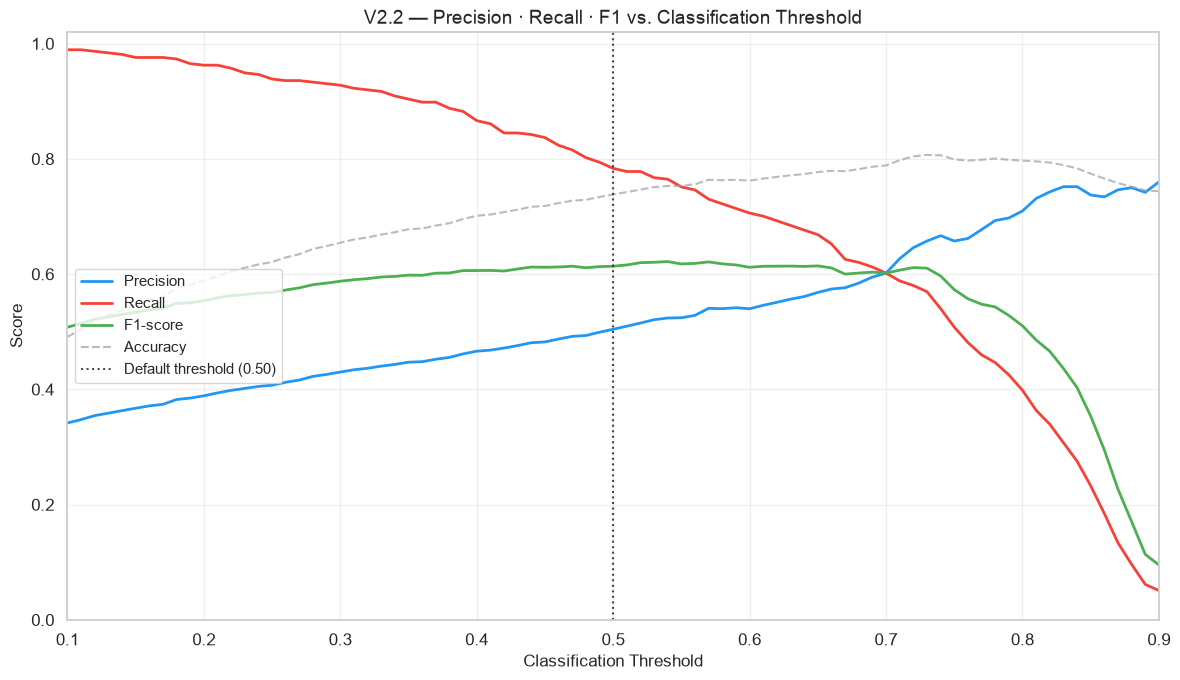

In [15]:
# ── Precision / Recall / F1 trade-off curve ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(v2_2_threshold_results["threshold"], v2_2_threshold_results["precision"],
        label="Precision", color="#2196F3", linewidth=2)
ax.plot(v2_2_threshold_results["threshold"], v2_2_threshold_results["recall"],
        label="Recall", color="#F44336", linewidth=2)
ax.plot(v2_2_threshold_results["threshold"], v2_2_threshold_results["f1"],
        label="F1-score", color="#4CAF50", linewidth=2)
ax.plot(v2_2_threshold_results["threshold"], v2_2_threshold_results["accuracy"],
        label="Accuracy", color="#9E9E9E", linewidth=1.5, linestyle="--", alpha=0.7)

ax.axvline(x=0.50, color="black", linestyle=":", linewidth=1.5, alpha=0.7,
           label="Default threshold (0.50)")

ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("V2.2 — Precision · Recall · F1 vs. Classification Threshold")
ax.legend(loc="center left", fontsize=11)
ax.set_xlim(0.10, 0.90)
ax.set_ylim(0.0, 1.02)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Section 8 — Best F1 Threshold for V2.2

We identify the threshold that maximises F1 for the class-weighted model.

In [16]:
best_f1_idx = v2_2_threshold_results["f1"].idxmax()
best_f1_row = v2_2_threshold_results.loc[best_f1_idx]
best_f1_threshold_v2_2 = best_f1_row["threshold"]

print("V2.2 — Best F1 Threshold")
print("=" * 50)
print(f"  Threshold : {best_f1_threshold_v2_2:.2f}")
print(f"  Precision : {best_f1_row['precision']:.4f}")
print(f"  Recall    : {best_f1_row['recall']:.4f}")
print(f"  F1-score  : {best_f1_row['f1']:.4f}")
print(f"  Accuracy  : {best_f1_row['accuracy']:.4f}")
print(f"  TP: {int(best_f1_row['tp'])}  FP: {int(best_f1_row['fp'])}  "
      f"FN: {int(best_f1_row['fn'])}  TN: {int(best_f1_row['tn'])}")
print("=" * 50)

V2.2 — Best F1 Threshold
  Threshold : 0.54
  Precision : 0.5238
  Recall    : 0.7647
  F1-score  : 0.6217
  Accuracy  : 0.7530
  TP: 286  FP: 260  FN: 88  TN: 775


In [17]:
# Comparison: V2.2 @ 0.50 vs V2.2 @ best F1
print("V2.2 — Default vs Best-F1 Threshold")
print("-" * 55)
print(f"{'':20s} {'@ 0.50':>12s} {'@ ' + str(best_f1_threshold_v2_2):>12s}")
print("-" * 55)
print(f"{'Precision':20s} {prec_v2_2:>12.4f} {best_f1_row['precision']:>12.4f}")
print(f"{'Recall':20s} {rec_v2_2:>12.4f} {best_f1_row['recall']:>12.4f}")
print(f"{'F1':20s} {f1_v2_2:>12.4f} {best_f1_row['f1']:>12.4f}")
print(f"{'Accuracy':20s} {acc_v2_2:>12.4f} {best_f1_row['accuracy']:>12.4f}")
print("-" * 55)

V2.2 — Default vs Best-F1 Threshold
-------------------------------------------------------
                           @ 0.50       @ 0.54
-------------------------------------------------------
Precision                  0.5043       0.5238
Recall                     0.7834       0.7647
F1                         0.6136       0.6217
Accuracy                   0.7381       0.7530
-------------------------------------------------------


---

## Section 9 — Consolidated Comparison: V1, V2.1, V2.2

This is the full picture — every experiment we've run so far, in one table.

In [18]:
# ── Compute V2.2 @ best-F1 confusion matrix stats ────────────────────
y_pred_best = (y_prob_v2_2 >= best_f1_threshold_v2_2).astype(int)
cm_best = confusion_matrix(y_test, y_pred_best)
tn_best, fp_best, fn_best, tp_best = cm_best.ravel()

# ── Build consolidated table ─────────────────────────────────────────
consolidated = pd.DataFrame({
    "": [
        "Model",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "",
        "True Positives",
        "False Positives",
        "False Negatives",
        "True Negatives",
    ],
    "V1": [
        "Standard LR",
        "0.50",
        f"{v1_metrics['accuracy']:.4f}",
        f"{v1_metrics['precision']:.4f}",
        f"{v1_metrics['recall']:.4f}",
        f"{v1_metrics['f1_score']:.4f}",
        f"{v1_metrics['roc_auc']:.4f}",
        "",
        str(int(tp_v1)),
        str(int(fp_v1)),
        str(int(fn_v1)),
        str(int(tn_v1)),
    ],
    "V2.1": [
        "Standard LR",
        str(v2_1_threshold),
        f"{v2_1_metrics['accuracy']:.4f}",
        f"{v2_1_metrics['precision']:.4f}",
        f"{v2_1_metrics['recall']:.4f}",
        f"{v2_1_metrics['f1']:.4f}",
        f"{v1_metrics['roc_auc']:.4f}",  # same model as V1
        "",
        str(v2_1_metrics["tp"]),
        str(v2_1_metrics["fp"]),
        str(v2_1_metrics["fn"]),
        str(v2_1_metrics["tn"]),
    ],
    "V2.2 @ 0.50": [
        "Class-Weighted LR",
        "0.50",
        f"{acc_v2_2:.4f}",
        f"{prec_v2_2:.4f}",
        f"{rec_v2_2:.4f}",
        f"{f1_v2_2:.4f}",
        f"{auc_v2_2:.4f}",
        "",
        str(int(tp_v2_2)),
        str(int(fp_v2_2)),
        str(int(fn_v2_2)),
        str(int(tn_v2_2)),
    ],
    "V2.2 @ Best F1": [
        "Class-Weighted LR",
        str(best_f1_threshold_v2_2),
        f"{best_f1_row['accuracy']:.4f}",
        f"{best_f1_row['precision']:.4f}",
        f"{best_f1_row['recall']:.4f}",
        f"{best_f1_row['f1']:.4f}",
        f"{auc_v2_2:.4f}",  # same model
        "",
        str(int(best_f1_row['tp'])),
        str(int(best_f1_row['fp'])),
        str(int(best_f1_row['fn'])),
        str(int(best_f1_row['tn'])),
    ],
})

print("Consolidated Experiment Comparison")
print("=" * 85)
print(consolidated.to_string(index=False))

Consolidated Experiment Comparison
                         V1        V2.1       V2.2 @ 0.50    V2.2 @ Best F1
          Model Standard LR Standard LR Class-Weighted LR Class-Weighted LR
      Threshold        0.50        0.27              0.50              0.54
       Accuracy      0.8055      0.7466            0.7381            0.7530
      Precision      0.6572      0.5149            0.5043            0.5238
         Recall      0.5588      0.7834            0.7834            0.7647
       F1-score      0.6040      0.6214            0.6136            0.6217
        ROC-AUC      0.8421      0.8421            0.8416            0.8416
                                                                           
 True Positives         209         293               293               286
False Positives         109         276               288               260
False Negatives         165          81                81                88
 True Negatives         926         759              

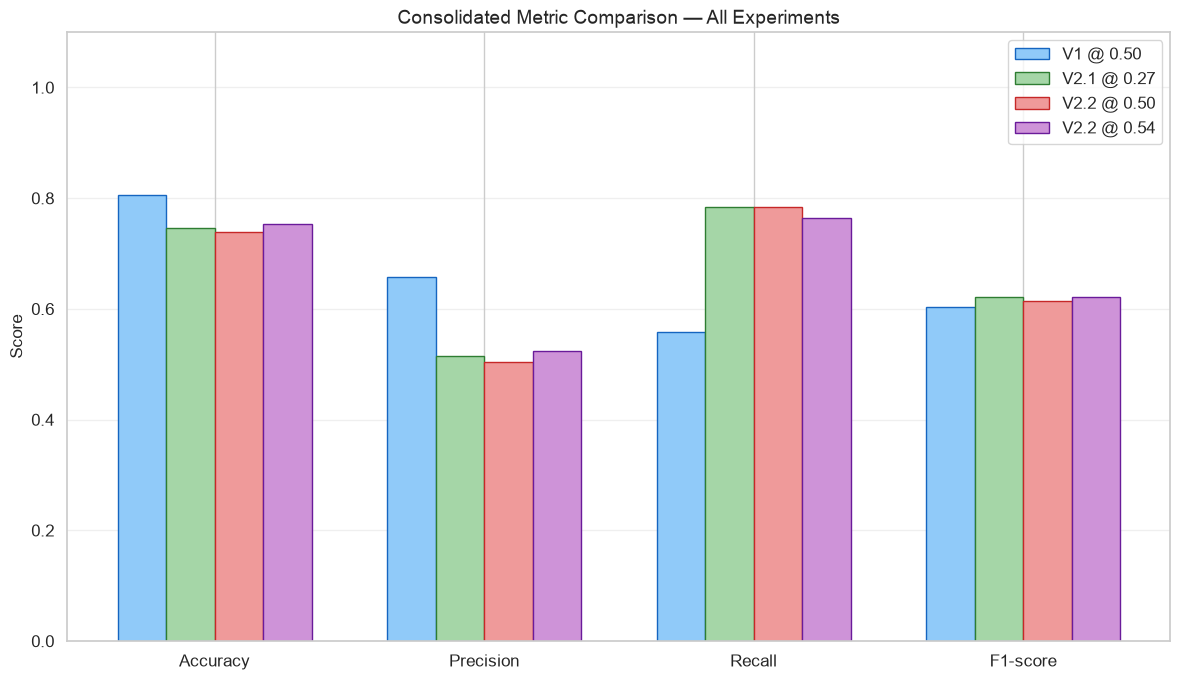

In [19]:
# ── Visual comparison of key metrics across all experiments ───────────
metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
v1_vals = [v1_metrics["accuracy"], v1_metrics["precision"],
           v1_metrics["recall"], v1_metrics["f1_score"]]
v21_vals = [v2_1_metrics["accuracy"], v2_1_metrics["precision"],
            v2_1_metrics["recall"], v2_1_metrics["f1"]]
v22_050_vals = [acc_v2_2, prec_v2_2, rec_v2_2, f1_v2_2]
v22_best_vals = [best_f1_row["accuracy"], best_f1_row["precision"],
                 best_f1_row["recall"], best_f1_row["f1"]]

x = np.arange(len(metric_names))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(x - 1.5*width, v1_vals, width, label="V1 @ 0.50", color="#90CAF9", edgecolor="#1565C0")
ax.bar(x - 0.5*width, v21_vals, width, label=f"V2.1 @ {v2_1_threshold}", color="#A5D6A7", edgecolor="#2E7D32")
ax.bar(x + 0.5*width, v22_050_vals, width, label="V2.2 @ 0.50", color="#EF9A9A", edgecolor="#C62828")
ax.bar(x + 1.5*width, v22_best_vals, width, label=f"V2.2 @ {best_f1_threshold_v2_2}", color="#CE93D8", edgecolor="#6A1B9A")

ax.set_ylabel("Score")
ax.set_title("Consolidated Metric Comparison — All Experiments")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend(loc="upper right")
ax.set_ylim(0, 1.10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

---

## Section 10 — Conceptual Interpretation

### The prediction pipeline — what changes where

```
V1:
  Standard Logistic Regression        →  Probability  →  0.50 threshold  →  Prediction
  (standard loss)                         P(churn)          cutoff

V2.1:
  Same Logistic Regression (V1)        →  Probability  →  0.27 threshold  →  Prediction
  (same coefficients as V1)               P(churn)          cutoff
                                          (identical)       (changed)

V2.2:
  Class-Weighted Logistic Regression   →  Probability  →  0.50 threshold  →  Prediction
  (different loss → different coefs)      P(churn)          cutoff
                                          (different!)      (default)
```

### Key distinction

**V2.1 changed the decision stage.** The model was the same — it produced the same probabilities. We just moved the cutoff lower to catch more positives.

**V2.2 changed the model stage.** The model is different — it produces *different probabilities* because it was trained with a different loss function. This means:

1. The probability distributions are shifted.
2. The coefficients are different.
3. The optimal threshold may also be different.

Both approaches can improve minority-class detection, but they are fundamentally different interventions:
- Threshold tuning is a **post-hoc** adjustment — cheap, instant, but limited by the model's discriminative ability.
- Class weighting is a **training-time** adjustment — it fundamentally changes what the model has learned.

---

## Section 11 — Business Interpretation

### What does class weighting accomplish from a business perspective?

Class weighting tells the model: *"It is more important to correctly identify churners than to correctly identify non-churners."*

This aligns with the telecom business reality:

| Scenario | Cost |
|----------|------|
| Missing a churner (FN) | Loss of customer lifetime value (CLV). Acquisition of a replacement costs 5–25× retention. Revenue lost permanently. |
| Flagging a loyal customer (FP) | Cost of a retention offer (discount, call, email). Often a small fraction of CLV. May even improve customer satisfaction. |

### Is the trade-off worthwhile?

This is **not** a question that can be answered purely with ML metrics. The answer depends on:

1. **Average CLV** — How much is a retained customer worth over their lifetime?
2. **Cost per retention action** — How much does a discount / call / email cost?
3. **Retention success rate** — What fraction of at-risk customers actually stay after a retention offer?
4. **Capacity** — Can the retention team handle the additional volume of flagged customers?

**Example calculation:**
- If CLV = $2,000 and each additional TP saves even 30% of churners, that's $600 saved per TP.
- If the cost of a false-positive retention offer is $20, then each FP costs $20.
- The breakeven ratio is: you can afford 30 extra FPs for each additional TP caught.

The actual numbers depend on the business. Our job as ML engineers is to provide the performance characteristics at each operating point so the business can make an informed decision.

---

## Section 12 — Save Model Artifact

We save the V2.2 pipeline as a **separate** artifact. The V1 model is **not overwritten**.

In [20]:
# ── Save V2.2 model ──────────────────────────────────────────────────
MODEL_DIR.mkdir(parents=True, exist_ok=True)

v2_2_model_path = MODEL_DIR / "churn_class_weighted_v2_2.joblib"
joblib.dump(model_v2_2, v2_2_model_path)
print(f"✓ V2.2 model saved to: {v2_2_model_path}")
print(f"  File size: {v2_2_model_path.stat().st_size / 1024:.1f} KB")

# ── Verify V1 model is untouched ─────────────────────────────────────
v1_model_path = MODEL_DIR / "churn_baseline_v1.joblib"
assert v1_model_path.exists(), "V1 model file is missing!"
print(f"✓ V1 model intact at: {v1_model_path}")

# ── Verify V2.2 model can load and predict ───────────────────────────
loaded_v2_2 = joblib.load(v2_2_model_path)
sample = X_test.iloc[:1]
sample_pred = loaded_v2_2.predict(sample)[0]
sample_prob = loaded_v2_2.predict_proba(sample)[0]

print(f"\nVerification — sample prediction from loaded V2.2 model:")
print(f"  Predicted class: {sample_pred} ({'Churn' if sample_pred == 1 else 'No Churn'})")
print(f"  P(No Churn)={sample_prob[0]:.4f}, P(Churn)={sample_prob[1]:.4f}")
print(f"  Actual label   : {y_test.iloc[0]}")
print(f"✓ V2.2 model loads and predicts successfully.")

✓ V2.2 model saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/models/churn_class_weighted_v2_2.joblib
  File size: 8.3 KB
✓ V1 model intact at: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/models/churn_baseline_v1.joblib



Verification — sample prediction from loaded V2.2 model:
  Predicted class: 0 (No Churn)
  P(No Churn)=0.8823, P(Churn)=0.1177
  Actual label   : 0
✓ V2.2 model loads and predicts successfully.


---

## Section 13 — Save Experiment Metrics

In [21]:
# ── Save V2.2 summary JSON ────────────────────────────────────────────
METRICS_DIR.mkdir(parents=True, exist_ok=True)

v2_2_summary = {
    "experiment": "V2.2 — Class-Weighted Logistic Regression",
    "model": "LogisticRegression(class_weight='balanced')",
    "model_artifact": str(v2_2_model_path),
    "random_state": RANDOM_STATE,
    "test_size": len(y_test),
    "train_size": len(y_train),
    "class_weights": {
        "class_0_NoChurn": round(float(weights[0]), 4),
        "class_1_Churn": round(float(weights[1]), 4),
    },
    "metrics_at_050": {
        "threshold": 0.50,
        "accuracy": round(acc_v2_2, 4),
        "precision": round(prec_v2_2, 4),
        "recall": round(rec_v2_2, 4),
        "f1": round(f1_v2_2, 4),
        "roc_auc": round(auc_v2_2, 4),
        "tp": int(tp_v2_2), "fp": int(fp_v2_2),
        "fn": int(fn_v2_2), "tn": int(tn_v2_2),
    },
    "best_f1_threshold": float(best_f1_threshold_v2_2),
    "metrics_at_best_f1": {
        "threshold": float(best_f1_threshold_v2_2),
        "accuracy": round(float(best_f1_row["accuracy"]), 4),
        "precision": round(float(best_f1_row["precision"]), 4),
        "recall": round(float(best_f1_row["recall"]), 4),
        "f1": round(float(best_f1_row["f1"]), 4),
        "roc_auc": round(auc_v2_2, 4),
        "tp": int(best_f1_row["tp"]), "fp": int(best_f1_row["fp"]),
        "fn": int(best_f1_row["fn"]), "tn": int(best_f1_row["tn"]),
    },
}

json_path = METRICS_DIR / "class_weighted_v2_2.json"
with open(json_path, "w") as f:
    json.dump(v2_2_summary, f, indent=2)
print(f"✓ V2.2 metrics saved to: {json_path}")

# ── Save threshold sweep CSV ────────────────────────────────────────
csv_path = METRICS_DIR / "class_weighted_threshold_analysis_v2_2.csv"
v2_2_threshold_results.to_csv(csv_path, index=False)
print(f"✓ V2.2 threshold sweep saved to: {csv_path}")

# ── Verify prior artifacts are intact ────────────────────────────────
for fname in ["baseline_v1.json", "threshold_analysis_v2_1.json",
              "threshold_analysis_v2_1.csv", "feature_definitions_v1.json"]:
    assert (METRICS_DIR / fname).exists(), f"{fname} is missing!"
print(f"✓ All prior metric files intact.")

✓ V2.2 metrics saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/class_weighted_v2_2.json
✓ V2.2 threshold sweep saved to: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/class_weighted_threshold_analysis_v2_2.csv
✓ All prior metric files intact.


---

## Section 14 — V2.2 Findings

In [22]:
print("=" * 70)
print("  IntelliPulse V2.2 — Class-Weighted Logistic Regression Findings")
print("=" * 70)
print()

# 1. Recall
print(f"  1. Recall (@ 0.50):")
print(f"     V1:   {v1_metrics['recall']:.4f}")
print(f"     V2.2: {rec_v2_2:.4f}  (Δ {rec_v2_2 - v1_metrics['recall']:+.4f})")
improved_recall = rec_v2_2 > v1_metrics["recall"]
print(f"     → Class weighting {'DID' if improved_recall else 'DID NOT'} improve recall.")
print()

# 2. Precision
print(f"  2. Precision (@ 0.50):")
print(f"     V1:   {v1_metrics['precision']:.4f}")
print(f"     V2.2: {prec_v2_2:.4f}  (Δ {prec_v2_2 - v1_metrics['precision']:+.4f})")
print()

# 3. F1
print(f"  3. F1-score (@ 0.50):")
print(f"     V1:   {v1_metrics['f1_score']:.4f}")
print(f"     V2.2: {f1_v2_2:.4f}  (Δ {f1_v2_2 - v1_metrics['f1_score']:+.4f})")
print()

# 4. ROC-AUC
print(f"  4. ROC-AUC:")
print(f"     V1:   {v1_metrics['roc_auc']:.4f}")
print(f"     V2.2: {auc_v2_2:.4f}  (Δ {auc_v2_2 - v1_metrics['roc_auc']:+.4f})")
print()

# 5. False Negatives
print(f"  5. False Negatives (missed churners):")
print(f"     V1:   {int(fn_v1)}")
print(f"     V2.2: {int(fn_v2_2)}  (Δ {int(fn_v2_2)-int(fn_v1):+d})")
print()

# 6. False Positives
print(f"  6. False Positives (false alarms):")
print(f"     V1:   {int(fp_v1)}")
print(f"     V2.2: {int(fp_v2_2)}  (Δ {int(fp_v2_2)-int(fp_v1):+d})")
print()

# 7. V2.2 vs V2.1
print(f"  7. V2.2 @ 0.50 vs V2.1 @ {v2_1_threshold}:")
print(f"     V2.1 Recall: {v2_1_metrics['recall']:.4f}  | V2.2 Recall: {rec_v2_2:.4f}")
print(f"     V2.1 F1:     {v2_1_metrics['f1']:.4f}  | V2.2 F1:     {f1_v2_2:.4f}")
print(f"     V2.1 FN:     {v2_1_metrics['fn']}     | V2.2 FN:     {int(fn_v2_2)}")
print()

# 8. Most promising approach
print(f"  8. Current assessment:")
if f1_v2_2 > v1_metrics["f1_score"] and f1_v2_2 >= v2_1_metrics["f1"]:
    print(f"     V2.2 (class-weighted LR @ 0.50) currently shows the best overall")
    print(f"     F1 balance, with improved recall over V1.")
elif v2_1_metrics["f1"] > f1_v2_2 and v2_1_metrics["recall"] > rec_v2_2:
    print(f"     V2.1 (threshold adjustment to {v2_1_threshold}) achieves higher recall")
    print(f"     than V2.2 @ 0.50. However, V2.2 may benefit from its own threshold")
    print(f"     tuning (best F1 @ {best_f1_threshold_v2_2}).")
else:
    print(f"     Results are mixed — no single approach dominates all metrics.")
    print(f"     The optimal choice depends on the business's recall/precision priority.")
print()
print(f"     V2.2 @ best F1 threshold ({best_f1_threshold_v2_2}):")
print(f"       Recall:    {best_f1_row['recall']:.4f}")
print(f"       Precision: {best_f1_row['precision']:.4f}")
print(f"       F1:        {best_f1_row['f1']:.4f}")
print()
print("  ⚠  No final production model is declared yet.")
print("     The next experiment will compare model families and evaluate robustness.")
print()
print("─" * 70)
print("  Next: Compare the threshold-adjusted / class-weighted Logistic")
print("  Regression baselines against alternative model approaches and")
print("  evaluate whether the observed improvements are robust.")
print("─" * 70)

  IntelliPulse V2.2 — Class-Weighted Logistic Regression Findings

  1. Recall (@ 0.50):
     V1:   0.5588
     V2.2: 0.7834  (Δ +0.2246)
     → Class weighting DID improve recall.

  2. Precision (@ 0.50):
     V1:   0.6572
     V2.2: 0.5043  (Δ -0.1529)

  3. F1-score (@ 0.50):
     V1:   0.6040
     V2.2: 0.6136  (Δ +0.0096)

  4. ROC-AUC:
     V1:   0.8421
     V2.2: 0.8416  (Δ -0.0005)

  5. False Negatives (missed churners):
     V1:   165
     V2.2: 81  (Δ -84)

  6. False Positives (false alarms):
     V1:   109
     V2.2: 288  (Δ +179)

  7. V2.2 @ 0.50 vs V2.1 @ 0.27:
     V2.1 Recall: 0.7834  | V2.2 Recall: 0.7834
     V2.1 F1:     0.6214  | V2.2 F1:     0.6136
     V2.1 FN:     81     | V2.2 FN:     81

  8. Current assessment:
     Results are mixed — no single approach dominates all metrics.
     The optimal choice depends on the business's recall/precision priority.

     V2.2 @ best F1 threshold (0.54):
       Recall:    0.7647
       Precision: 0.5238
       F1:       

---

*End of IntelliPulse V2.2 — Class-Weighted Logistic Regression*